Descargando KO y PEP...


[*********************100%***********************]  2 of 2 completed


Hedge Ratio (Beta): 0.9811
R-squared: 0.9557
ADF Statistic: -1.9119
p-value: 0.3265
ALERTA: El spread NO es estacionario (No hay cointegración).


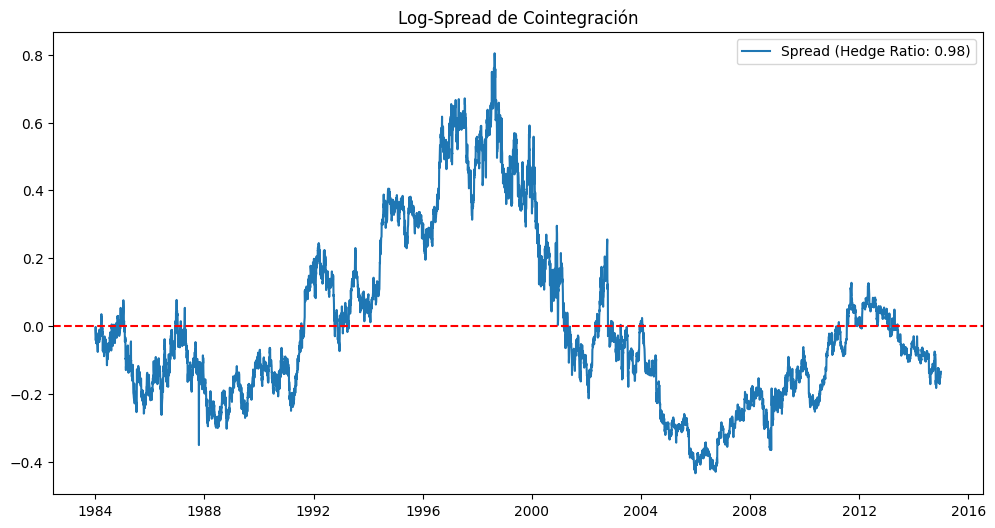

In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

def extract_and_construct_spread(ticker_A, ticker_B, start_date, end_date):
    """
    Descarga datos, calcula el Hedge Ratio via OLS y construye el Spread.
    
    Args:
        ticker_A (str): Ticker del activo dependiente (ej. 'GLD').
        ticker_B (str): Ticker del activo independiente (ej. 'GDX').
        start_date (str): Fecha inicio 'YYYY-MM-DD'.
        end_date (str): Fecha fin 'YYYY-MM-DD'.
        
    Returns:
        pd.Series: El spread histórico (z-score).
        float: El Hedge Ratio (beta).
    """
    
    # 1. Descarga de datos (Solo 'Adj Close' para ajustar por dividendos/splits)
    print(f"Descargando {ticker_A} y {ticker_B}...")
    data = yf.download([ticker_A, ticker_B], start=start_date, end=end_date, auto_adjust=False)['Adj Close']
    
    # Limpieza de datos (eliminar filas con NaN)
    data = data.dropna()
    
    if data.empty:
        raise ValueError("No se descargaron datos. Verifica los tickers o fechas.")

    # 2. Convertir a Log-Precios
    # Usamos log natural
    log_A = np.log(data[ticker_A])
    log_B = np.log(data[ticker_B])
    
    # 3. Calcular Hedge Ratio (Beta) usando OLS (Mínimos Cuadrados Ordinarios)
    # Ecuación: log_A = beta * log_B + alpha + error
    # Añadimos una constante (intercepto/alpha) a la regresión
    X = sm.add_constant(log_B)
    model = sm.OLS(log_A, X).fit()
    
    alpha = model.params['const']
    beta = model.params[ticker_B]
    
    print(f"Hedge Ratio (Beta): {beta:.4f}")
    print(f"R-squared: {model.rsquared:.4f}")
    
    # 4. Construir el Spread Bruto
    # spread = y - (beta * x + alpha)
    # Nota: En trading real, a veces ignoramos alpha y solo operamos A - beta*B
    # Pero para el modelo OU riguroso, usamos el residuo completo.
    raw_spread = log_A - (beta * log_B + alpha)
    
    # 5. Test de Estacionariedad (ADF Test)
    # El spread DEBE ser estacionario para que funcione el par.
    adf_result = adfuller(raw_spread)
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    
    if adf_result[1] > 0.05:
        print("ALERTA: El spread NO es estacionario (No hay cointegración).")
    else:
        print("ÉXITO: El spread es estacionario (Cointegrado).")

    return raw_spread, beta

# --- EJECUCIÓN ---
# Ejemplo clásico: Oro (GLD) vs Mineras de Oro (GDX)
# Nota: En 2026 este par está muy arbitrado, pero sirve de ejemplo académico.
try:
    spread_series, hedge_ratio = extract_and_construct_spread('KO', 'PEP', '1984-01-01', '2015-01-01')

    # Visualización rápida
    plt.figure(figsize=(12, 6))
    plt.plot(spread_series, label=f'Spread (Hedge Ratio: {hedge_ratio:.2f})')
    plt.axhline(spread_series.mean(), color='red', linestyle='--')
    plt.title('Log-Spread de Cointegración')
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")

[*********************100%***********************]  2 of 2 completed


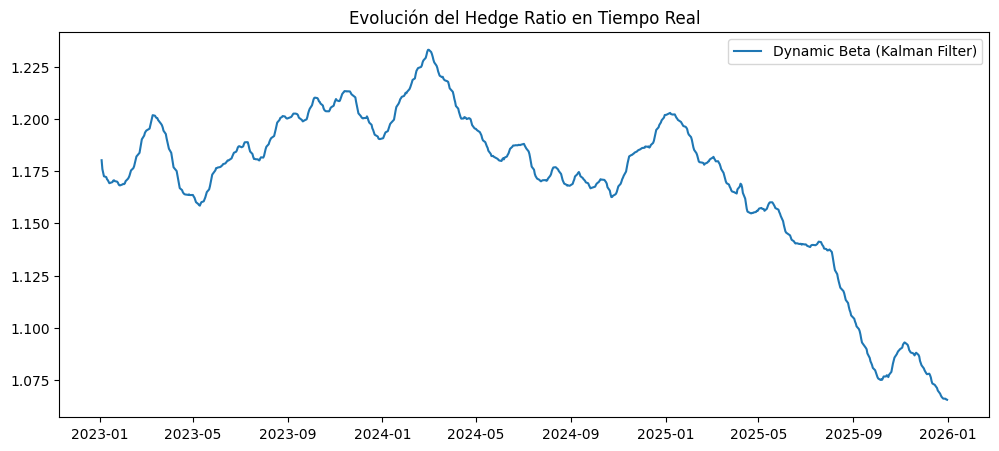

In [30]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def kalman_filter_pair_trading(ticker_A, ticker_B, start, end):
    # 1. Obtención de datos
    data = yf.download([ticker_A, ticker_B], start=start, end=end, auto_adjust=False)['Adj Close'].dropna()
    x = np.log(data[ticker_B].values)
    y = np.log(data[ticker_A].values)

    # 2. Inicialización de variables del Filtro de Kalman
    # Estado inicial [beta, alpha]
    state_means = np.zeros(2)
    # Incertidumbre inicial (Covarianza del estado)
    state_cov = np.ones((2, 2))
    
    # Parámetros de ruido (Hiperparámetros)
    # Q: Covarianza del proceso (qué tan rápido cambian beta y alpha)
    # R: Covarianza de la medición (ruido en los precios)
    Q = 1e-5 * np.eye(2)
    R = 0.01
    
    betas = []
    alphas = []
    spreads = []

    # 3. Bucle del Filtro (Online Learning)
    for t in range(len(y)):
        # --- PASO DE PREDICCIÓN ---
        # El estado esperado es igual al anterior (Paseo Aleatorio)
        # La covarianza aumenta por el ruido del proceso Q
        state_cov = state_cov + Q
        
        # --- PASO DE ACTUALIZACIÓN ---
        # Vector de observación H (los datos del activo B hoy)
        H = np.array([x[t], 1.0])
        
        # Innovación (Error de predicción)
        prediction = np.dot(H, state_means)
        innovation = y[t] - prediction
        
        # Covarianza de la innovación
        innovation_cov = np.dot(H, np.dot(state_cov, H.T)) + R
        
        # Ganancia de Kalman (K)
        K = np.dot(state_cov, H.T) / innovation_cov
        
        # Actualizar estado e incertidumbre
        state_means = state_means + K * innovation
        state_cov = state_cov - np.outer(K, np.dot(H, state_cov))
        
        # Guardar resultados
        betas.append(state_means[0])
        alphas.append(state_means[1])
        spreads.append(innovation) # El spread es la innovación/error

    # 4. Resultados
    results = pd.DataFrame(index=data.index)
    results['beta'] = betas
    results['alpha'] = alphas
    results['spread'] = spreads
    
    return results

# Ejecución
kf_results = kalman_filter_pair_trading('GLD', 'GDX', '2023-01-01', '2026-01-01')

# Visualización del Hedge Ratio Dinámico
plt.figure(figsize=(12, 5))
plt.plot(kf_results['beta'], label='Dynamic Beta (Kalman Filter)')
plt.title('Evolución del Hedge Ratio en Tiempo Real')
plt.legend()
plt.show()

In [36]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

def backtest_pair_trading(ticker_A, ticker_B, start, end, window=60, entry_z=2.0, exit_z=0, cost=0.001):
    # 1. Descarga y preparación
    data = yf.download([ticker_A, ticker_B], start=start, end=end, auto_adjust=False)['Adj Close'].dropna()
    log_prices = np.log(data)
    
    # DataFrame para resultados
    results = pd.DataFrame(index=log_prices.index)
    results['log_A'] = log_prices[ticker_A]
    results['log_B'] = log_prices[ticker_B]
    
    #Use kalman filter para obtener beta dinámico
    kf_results = kalman_filter_pair_trading(ticker_A, ticker_B, start, end)
    betas = kf_results['beta'].values
    spreads = kf_results['spread'].values

    results['beta'] = betas
    results['spread'] = spreads
    
    # 3. Normalización (Z-Score)
    results['mean'] = results['spread'].rolling(window=window).mean()
    results['std'] = results['spread'].rolling(window=window).std()
    results['z_score'] = (results['spread'] - results['mean']) / results['std']
    
    # 4. Lógica de Trading (Vectorizada)
    # Posición: 1 (Long Spread), -1 (Short Spread), 0 (Neutral)
    results['position'] = 0
    curr_pos = 0
    positions = []
    
    for z in results['z_score']:
        if np.isnan(z):
            positions.append(0)
            continue
        
        if curr_pos == 0:
            if z > entry_z: curr_pos = -1 # Short A, Long B
            elif z < -entry_z: curr_pos = 1 # Long A, Short B
        elif curr_pos == 1 and z >= exit_z:
            curr_pos = 0 # Cerrar Long
        elif curr_pos == -1 and z <= exit_z:
            curr_pos = 0 # Cerrar Short
            
        positions.append(curr_pos)
    
    results['position'] = positions
    
    # 5. Cálculo de Retornos
    # Retorno del spread = d(Spread)
    # Nota: Simplificación para propósitos académicos
    results['returns_A'] = results['log_A'].diff()
    results['returns_B'] = results['log_B'].diff()
    
    # Retorno estrategia = Posicion_t-1 * (Ret_A - Beta * Ret_B)
    results['strategy_ret'] = results['position'].shift(1) * (results['returns_A'] - results['beta'] * results['returns_B'])
    
    # Aplicar costes de transacción (cuando la posición cambia)
    trades = results['position'].diff().fillna(0) != 0
    results['strategy_ret'] = results['strategy_ret'] - (trades * cost)
    
    # 6. Métricas
    cum_ret = results['strategy_ret'].cumsum().apply(np.exp)
    sharpe = (results['strategy_ret'].mean() / results['strategy_ret'].std()) * np.sqrt(252)
    
    return results, sharpe, cum_ret

# Ejemplo práctico
res, sharpe, equity = backtest_pair_trading('KO', 'PEP', '2001-01-01', '2002-01-01')
print(f"Sharpe Ratio del Backtest: {sharpe:.2f}")

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed

Sharpe Ratio del Backtest: 0.19


In [7]:
import numpy as np
import pandas as pd

def fit_ornstein_uhlenbeck(spread_series, dt=1.0):
    """
    Calibra los parámetros de un proceso Ornstein-Uhlenbeck usando
    regresión lineal (equivalente a MLE para distribución Gaussiana).
    
    Modelo: dXt = theta * (mu - Xt) * dt + sigma * dWt
    
    Args:
        spread_series (np.array): Serie de tiempo del spread (precios).
        dt (float): Paso de tiempo (ej. 1/252 para datos diarios anualizados).
        
    Returns:
        dict: Parámetros estimados {theta, mu, sigma} y métricas de ajuste.
    """
    # 1. Preparar vectores para regresión X(t+1) = a * X(t) + b
    # x_t es el spread actual, x_t_plus_1 es el spread en el siguiente paso
    x_t = spread_series[:-1]
    x_t_plus_1 = spread_series[1:]
    
    # 2. Regresión Lineal (OLS Vectorizado)
    # y = mx + c -> x_t_plus_1 = a * x_t + b
    # Usamos np.polyfit para eficiencia (grado 1)
    a, b = np.polyfit(x_t, x_t_plus_1, 1)
    
    # Calcular residuos para obtener la varianza del ruido
    residuals = x_t_plus_1 - (a * x_t + b)
    sigma_eta_std = np.std(residuals) # Desviación estándar de los residuos
    
    # 3. Recuperar parámetros físicos (theta, mu, sigma)
    # theta = -ln(a) / dt
    # Nota: Si a > 1, el proceso es explosivo (no estacionario), theta será negativo.
    theta = -np.log(a) / dt
    
    # mu = b / (1 - a)
    mu = b / (1 - a)
    
    # sigma (volatilidad del proceso continuo)
    # sigma_eta^2 = sigma^2 * (1 - e^(-2*theta*dt)) / (2*theta)
    # Se despeja sigma:
    sigma = sigma_eta_std * np.sqrt( (2 * theta) / (1 - a**2) )
    
    # 4. Cálculo de Half-Life (Vida Media del trade)
    half_life = np.log(2) / theta
    
    return {
        "theta (Mean Reversion Speed)": theta,
        "mu (Long Term Mean)": mu,
        "sigma (Volatility)": sigma,
        "half_life": half_life,
        "is_stationary": theta > 0  # Si theta < 0, el spread diverge
    }

# Ejemplo de uso (simulado)
np.random.seed(42)
# Generamos un spread sintético para probar
dummy_spread = np.random.normal(0, 1, 100).cumsum() 
# Nota: cumsum es Random Walk, theta debería ser cercano a 0 (no estacionario)
results = fit_ornstein_uhlenbeck(dummy_spread)

print("Resultados de Calibración:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Resultados de Calibración:
theta (Mean Reversion Speed): 0.0271
mu (Long Term Mean): -10.4725
sigma (Volatility): 0.9098
half_life: 25.5555
is_stationary: 1.0000
